# Exploratory Data Analysis — HIGGS Dataset

**Project:** Quantum Machine Learning for Particle Physics (IT401)  
**Paper:** Blance & Spannowsky, *Quantum Machine Learning for Particle Physics using a Variational Quantum Classifier*, JHEP 02 (2021) 212

**Purpose:** Understand the structure, distributions, and quality of the HIGGS dataset before feeding it into VQC experiments. This notebook covers:

1. Data loading & basic info  
2. Missing values & data types  
3. Class balance analysis  
4. Feature distributions (signal vs. background)  
5. Correlation analysis  
6. Feature importance ranking (w.r.t. label)  
7. Feature pair analysis (for the paper's 2-feature setup)  
8. Outlier detection  
9. Scaling preview (MinMax to [0, π])  
10. Cleaned data export & recommendations

---

### HIGGS Dataset — Feature Reference

| Index | Name | Type | Description |
|-------|------|------|-------------|
| 0 | **label** | Target | 1 = signal, 0 = background |
| 1 | lepton pT | Low-level | Transverse momentum of the lepton |
| 2 | lepton eta | Low-level | Pseudorapidity of the lepton |
| 3 | lepton phi | Low-level | Azimuthal angle of the lepton |
| 4 | missing energy magnitude | Low-level | Missing transverse energy (MET) |
| 5 | missing energy phi | Low-level | Azimuthal angle of MET |
| 6 | jet 1 pt | Low-level | Transverse momentum of leading jet |
| 7 | jet 1 eta | Low-level | Pseudorapidity of leading jet |
| 8 | jet 1 phi | Low-level | Azimuthal angle of leading jet |
| 9 | jet 1 b-tag | Low-level | b-tagging score of leading jet |
| 10 | jet 2 pt | Low-level | Transverse momentum of sub-leading jet |
| 11 | jet 2 eta | Low-level | Pseudorapidity of sub-leading jet |
| 12 | jet 2 phi | Low-level | Azimuthal angle of sub-leading jet |
| 13 | jet 2 b-tag | Low-level | b-tagging score of sub-leading jet |
| 14 | jet 3 pt | Low-level | Transverse momentum of 3rd jet |
| 15 | jet 3 eta | Low-level | Pseudorapidity of 3rd jet |
| 16 | jet 3 phi | Low-level | Azimuthal angle of 3rd jet |
| 17 | jet 3 b-tag | Low-level | b-tagging score of 3rd jet |
| 18 | jet 4 pt | Low-level | Transverse momentum of 4th jet |
| 19 | jet 4 eta | Low-level | Pseudorapidity of 4th jet |
| 20 | jet 4 phi | Low-level | Azimuthal angle of 4th jet |
| 21 | jet 4 b-tag | Low-level | b-tagging score of 4th jet |
| 22 | m_jj | High-level | Invariant mass of two leading jets |
| 23 | m_jjj | High-level | Invariant mass of three leading jets |
| 24 | m_lv | High-level | Invariant mass of lepton + MET |
| 25 | m_jlv | High-level | Invariant mass of jet + lepton + MET |
| 26 | m_bb | High-level | Invariant mass of two b-tagged jets |
| 27 | m_wbb | High-level | Invariant mass of W + b-tagged jets |
| 28 | m_wwbb | High-level | Invariant mass of WW + bb system |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot style
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
})

sns.set_style("whitegrid")
print("Libraries loaded successfully.")

Libraries loaded successfully.


## 1. Data Loading & Basic Information

We load the first 5,000 samples to match the paper's setup. The full HIGGS dataset has ~11 million events, but the VQC experiments use a 5,000-sample subset.

In [2]:
# ── CONFIGURE PATH ──
DATA_PATH = '../data/HIGGS.csv.gz'   # Adjust if your file is elsewhere
N_SAMPLES = 5000                      # Paper uses 5000

# Feature names (column 0 = label, columns 1–28 = features)
FEATURE_NAMES = [
    'label',
    'lepton_pT', 'lepton_eta', 'lepton_phi',
    'missing_energy_mag', 'missing_energy_phi',
    'jet1_pt', 'jet1_eta', 'jet1_phi', 'jet1_btag',
    'jet2_pt', 'jet2_eta', 'jet2_phi', 'jet2_btag',
    'jet3_pt', 'jet3_eta', 'jet3_phi', 'jet3_btag',
    'jet4_pt', 'jet4_eta', 'jet4_phi', 'jet4_btag',
    'M_jj', 'M_jjj', 'M_lv', 'M_jlv', 'M_bb', 'M_wbb', 'M_wwbb'
]

LOW_LEVEL = FEATURE_NAMES[1:22]    # 21 low-level features
HIGH_LEVEL = FEATURE_NAMES[22:]     # 7 high-level features

# Load data
data = pd.read_csv(DATA_PATH, header=None, compression='gzip', nrows=N_SAMPLES)
data.columns = FEATURE_NAMES

print(f"Shape: {data.shape}")
print(f"Rows: {data.shape[0]:,}  |  Columns: {data.shape[1]}")
data.head()

Shape: (5000, 29)
Rows: 5,000  |  Columns: 29


,label,lepton_pT,lepton_eta,lepton_phi,missing_energy_mag,missing_energy_phi,jet1_pt,jet1_eta,jet1_phi,jet1_btag,...,jet4_eta,jet4_phi,jet4_btag,M_jj,M_jjj,M_lv,M_jlv,M_bb,M_wbb,M_wwbb
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


## 2. Data Quality Check — Missing Values, Types & Duplicates

In [3]:
# Missing values
missing = data.isnull().sum()
missing_pct = (missing / len(data) * 100).round(2)

print("=" * 50)
print("MISSING VALUES SUMMARY")
print("=" * 50)
print(f"Total missing values : {missing.sum()}")
print(f"Columns with missing : {(missing > 0).sum()}")

if missing.sum() > 0:
    print("\nColumns with missing values:")
    print(missing[missing > 0].to_frame('count').assign(pct=missing_pct[missing > 0]))
else:
    print("\n✅ No missing values found — dataset is clean.")

print("\n" + "=" * 50)
print("DATA TYPES")
print("=" * 50)
print(data.dtypes.value_counts().to_frame('count'))

# Duplicates
n_dupes = data.duplicated().sum()
print(f"\nDuplicate rows: {n_dupes}")
if n_dupes > 0:
    print(f"  → {n_dupes} duplicates found — will be removed.")
    data = data.drop_duplicates().reset_index(drop=True)
    print(f"  → After removal: {len(data)} rows")
else:
    print("✅ No duplicates found.")

MISSING VALUES SUMMARY
Total missing values : 0
Columns with missing : 0

✅ No missing values found — dataset is clean.

DATA TYPES
         count
float64     29

Duplicate rows: 0
✅ No duplicates found.


## 3. Summary Statistics

In [4]:
# Descriptive statistics for all features
desc = data.describe().T
desc['range'] = desc['max'] - desc['min']
desc['iqr'] = desc['75%'] - desc['25%']
desc['cv'] = (desc['std'] / desc['mean'].abs()).round(3)  # coeff of variation

print("Summary Statistics (all 28 features + label):\n")
desc[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max', 'range', 'iqr']].round(4)

Summary Statistics (all 28 features + label):



,count,mean,std,min,25%,50%,75%,max,range,iqr
label,5000.0,0.5340,0.4989,0.0000,0.0000,1.0000,1.0000,1.0000,1.0000,1.0000
lepton_pT,5000.0,1.0128,0.5935,0.2751,0.6028,0.8687,1.2556,6.6954,6.4203,0.6527
lepton_eta,5000.0,-0.0157,0.9999,-2.4174,-0.7325,-0.0195,0.7073,2.4300,4.8474,1.4398
lepton_phi,5000.0,-0.0113,1.0082,-1.7425,-0.8737,-0.0108,0.8512,1.7432,3.4857,1.7249
missing_energy_mag,5000.0,0.9799,0.5904,0.0187,0.5626,0.8734,1.2741,5.7002,5.6814,0.7116
missing_energy_phi,5000.0,-0.0207,1.0014,-1.7426,-0.8963,-0.0461,0.8385,1.7425,3.4851,1.7348
jet1_pt,5000.0,1.0004,0.4789,0.1783,0.6848,0.9008,1.1786,4.1900,4.0118,0.4938
jet1_eta,5000.0,0.0055,1.0006,-2.9410,-0.6724,-0.0060,0.6773,2.9697,5.9107,1.3497
jet1_phi,5000.0,0.0140,1.0045,-1.7412,-0.8642,0.0329,0.8740,1.7415,3.4827,1.7382
jet1_btag,5000.0,1.0137,1.0270,0.0000,0.0000,1.0865,2.1731,2.1731,2.1731,2.1731


## 4. Class Balance Analysis

The paper uses a balanced dataset of 2,500 signal and 2,500 background events. Let's verify.

Class Distribution:
  Background (0): 2,330  (46.6%)
  Signal     (1): 2,670  (53.4%)
  Ratio (sig/bg): 1.146


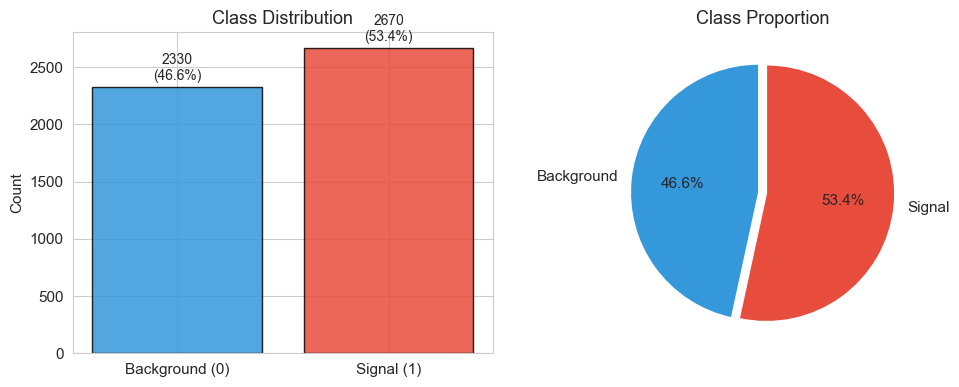


⚠️  Imbalance ratio: 1.15 — consider stratified sampling.


In [5]:
# Class distribution
class_counts = data['label'].value_counts().sort_index()
class_pct = (class_counts / len(data) * 100).round(1)

print("Class Distribution:")
print(f"  Background (0): {class_counts[0.0]:>5,}  ({class_pct[0.0]:.1f}%)")
print(f"  Signal     (1): {class_counts[1.0]:>5,}  ({class_pct[1.0]:.1f}%)")
print(f"  Ratio (sig/bg): {class_counts[1.0] / class_counts[0.0]:.3f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar chart
bars = axes[0].bar(['Background (0)', 'Signal (1)'], class_counts.values,
                    color=['#3498db', '#e74c3c'], edgecolor='black', alpha=0.85)
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution')
for bar, count, pct in zip(bars, class_counts.values, class_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{count}\n({pct}%)', ha='center', va='bottom', fontsize=10)

# Pie chart
axes[1].pie(class_counts.values, labels=['Background', 'Signal'],
            colors=['#3498db', '#e74c3c'], autopct='%1.1f%%',
            startangle=90, explode=(0.03, 0.03))
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.show()

# Check if balanced
imbalance_ratio = max(class_counts) / min(class_counts)
if imbalance_ratio < 1.1:
    print("\n✅ Dataset is approximately balanced — no resampling needed.")
else:
    print(f"\n⚠️  Imbalance ratio: {imbalance_ratio:.2f} — consider stratified sampling.")

## 5. Feature Distributions — Signal vs. Background

Visualizing how each feature distributes across signal and background classes helps identify which features have the most discriminating power.

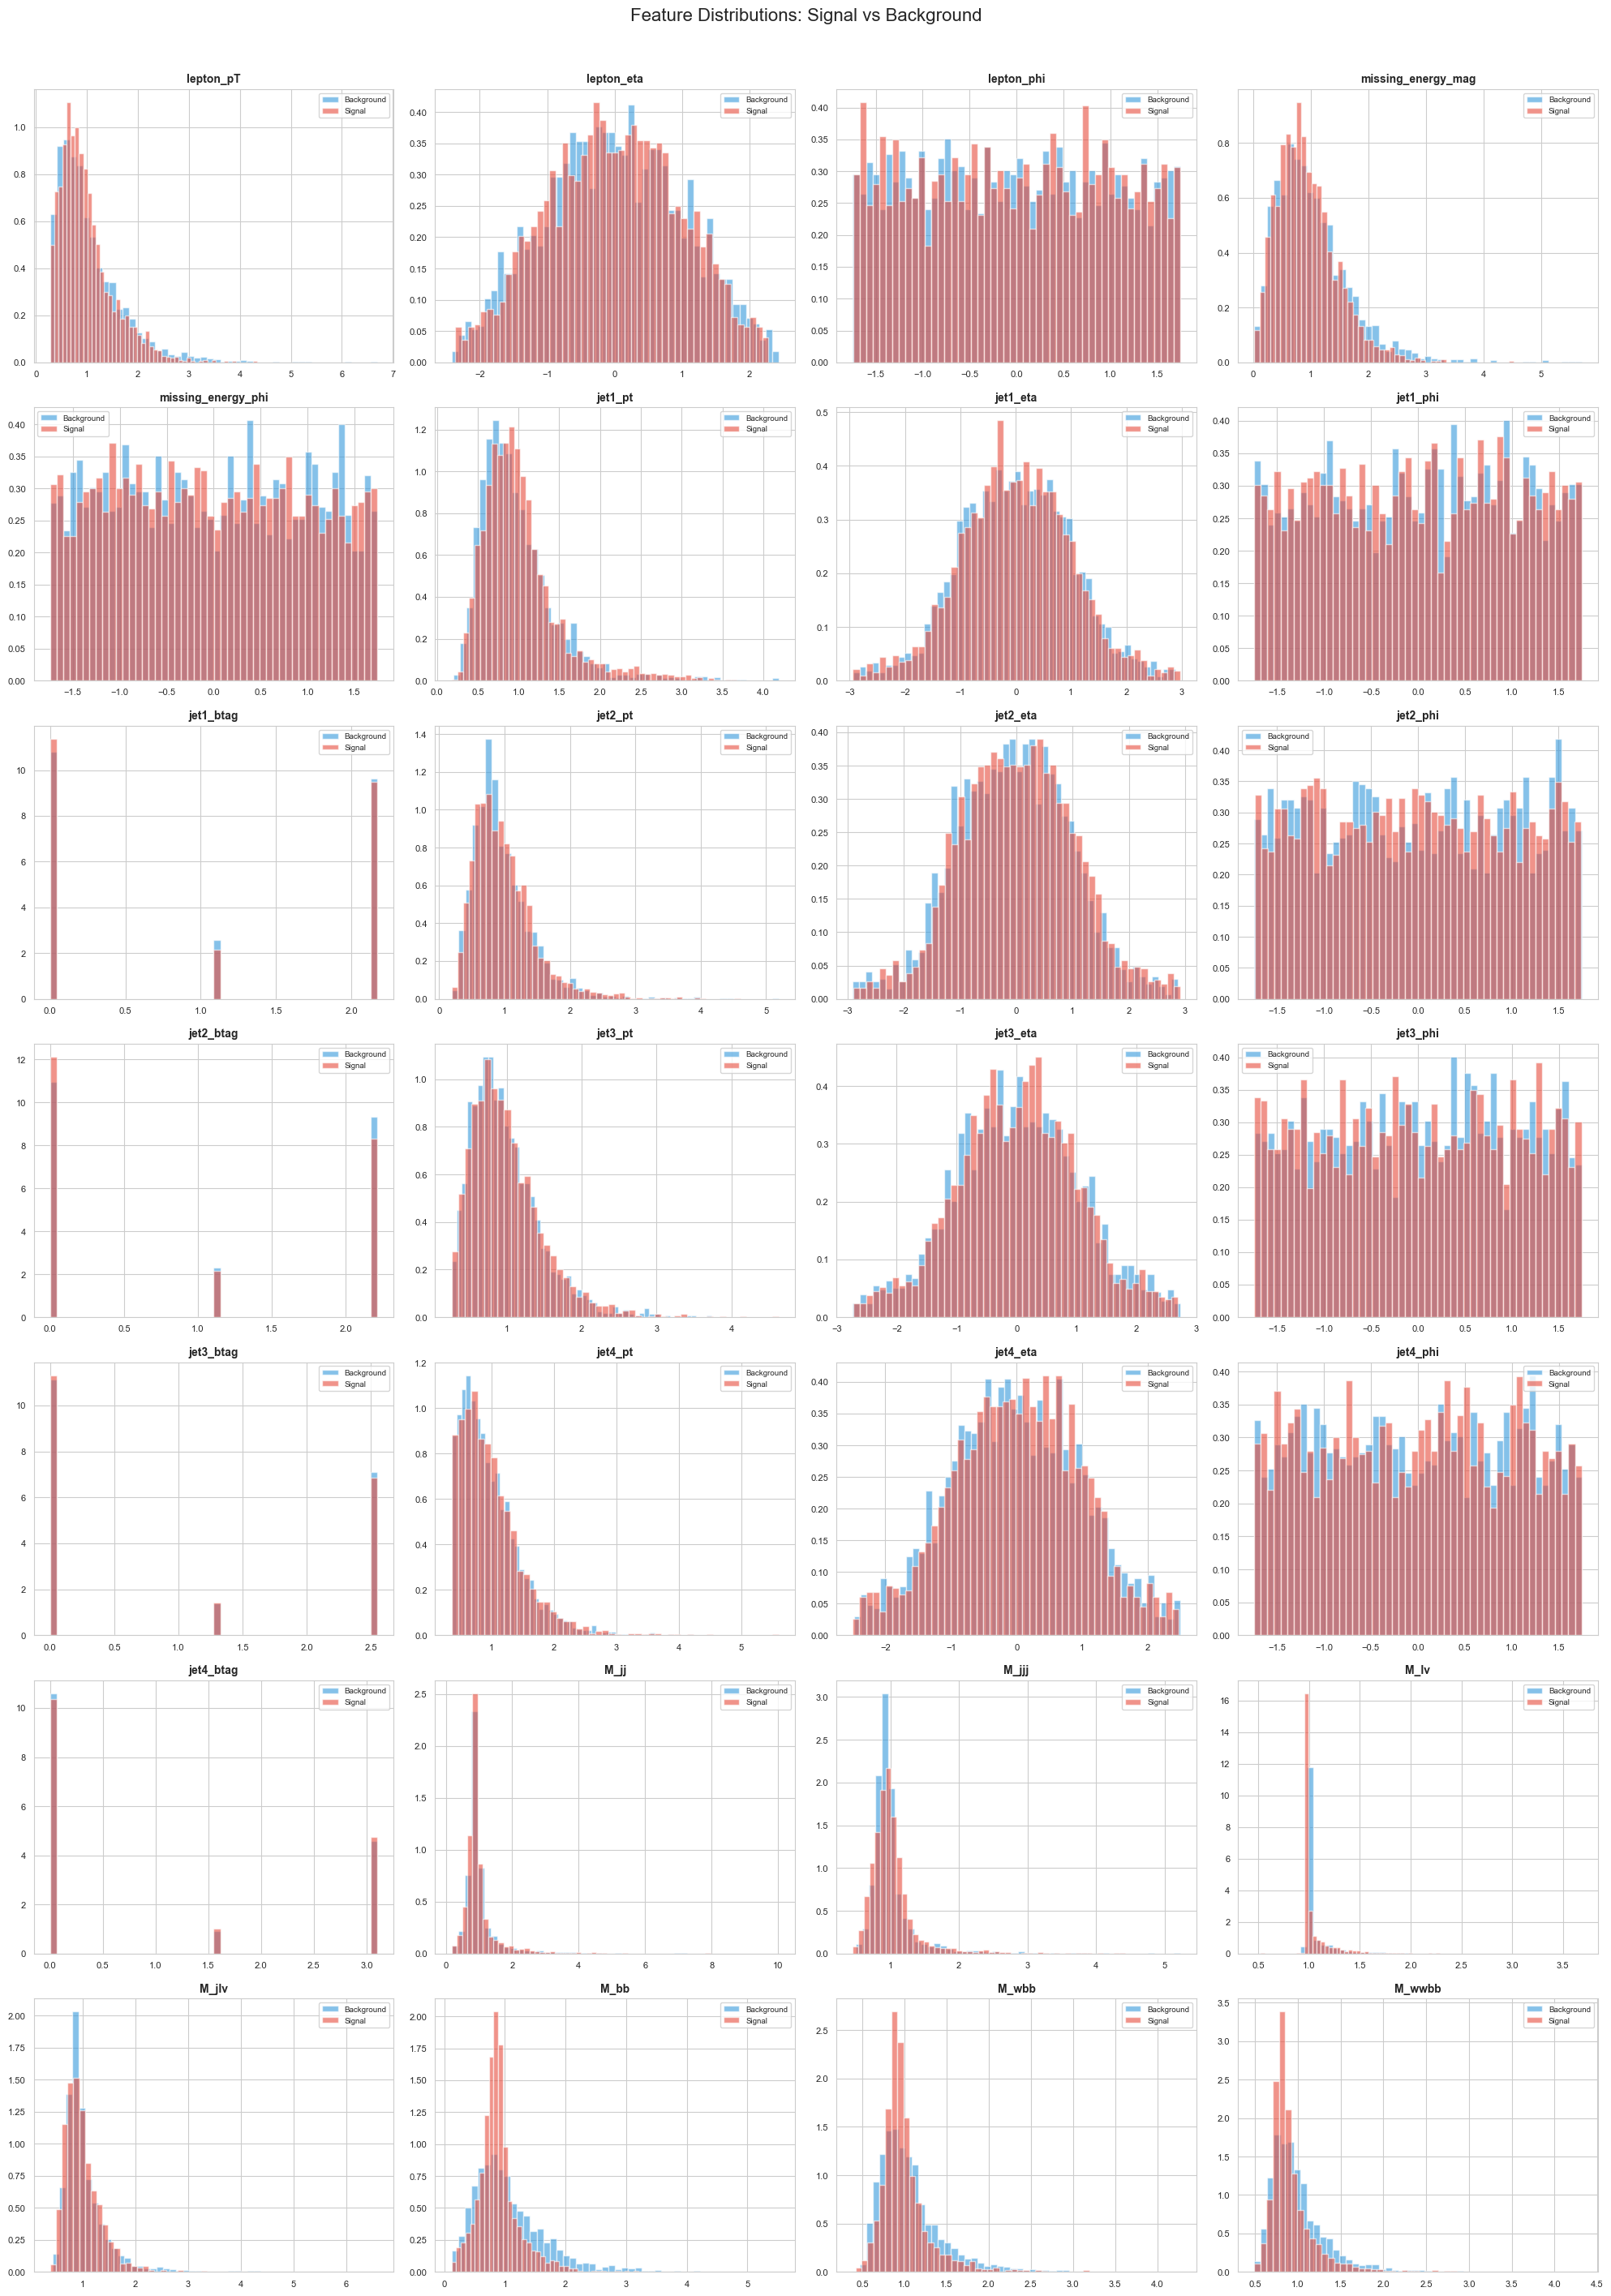

In [6]:
# Split by class
signal = data[data['label'] == 1.0]
background = data[data['label'] == 0.0]

features = FEATURE_NAMES[1:]  # exclude label

fig, axes = plt.subplots(7, 4, figsize=(20, 28))
axes = axes.flatten()

for i, feat in enumerate(features):
    ax = axes[i]
    ax.hist(background[feat], bins=50, alpha=0.6, label='Background', color='#3498db', density=True)
    ax.hist(signal[feat], bins=50, alpha=0.6, label='Signal', color='#e74c3c', density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

# Remove empty subplots
for j in range(len(features), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Feature Distributions: Signal vs Background', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 5b. Low-level vs High-level Feature Comparison

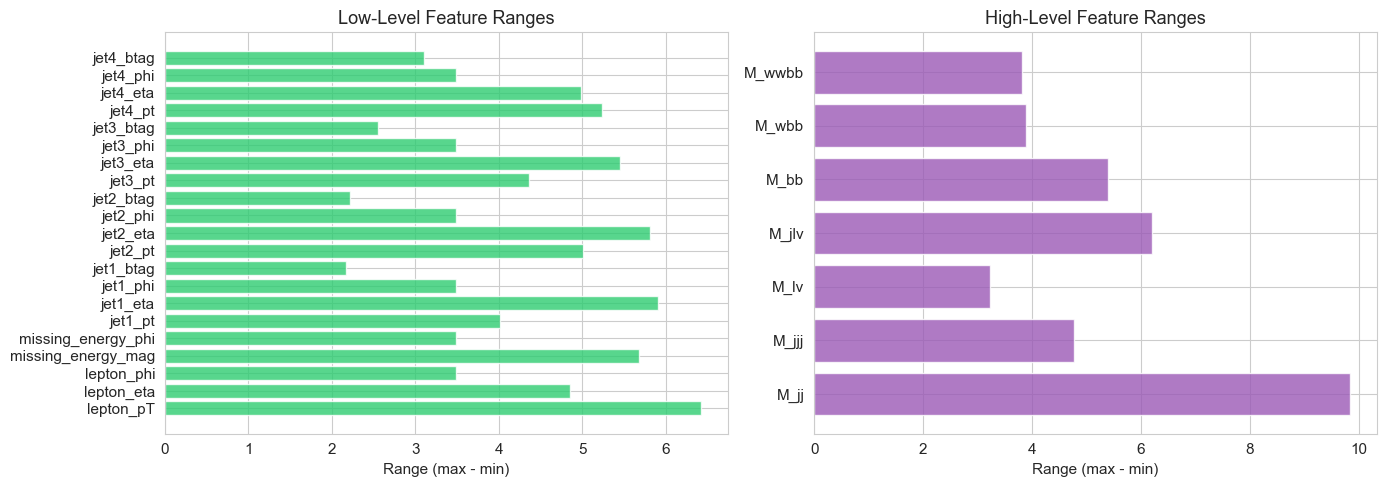

Low-level features: Raw detector measurements (pT, eta, phi, b-tag)
High-level features: Derived invariant masses (m_jj, m_jjj, etc.)

Low-level avg range:  4.222
High-level avg range: 5.305


In [7]:
# Compare distributions of low-level vs high-level features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Low-level feature ranges
low_ranges = data[LOW_LEVEL].apply(lambda x: x.max() - x.min())
high_ranges = data[HIGH_LEVEL].apply(lambda x: x.max() - x.min())

axes[0].barh(LOW_LEVEL, low_ranges.values, color='#2ecc71', alpha=0.8)
axes[0].set_title('Low-Level Feature Ranges')
axes[0].set_xlabel('Range (max - min)')

axes[1].barh(HIGH_LEVEL, high_ranges.values, color='#9b59b6', alpha=0.8)
axes[1].set_title('High-Level Feature Ranges')
axes[1].set_xlabel('Range (max - min)')

plt.tight_layout()
plt.show()

print("Low-level features: Raw detector measurements (pT, eta, phi, b-tag)")
print("High-level features: Derived invariant masses (m_jj, m_jjj, etc.)")
print(f"\nLow-level avg range:  {low_ranges.mean():.3f}")
print(f"High-level avg range: {high_ranges.mean():.3f}")

## 6. Correlation Analysis

We examine correlations between features and with the label to understand which features carry the most signal information.

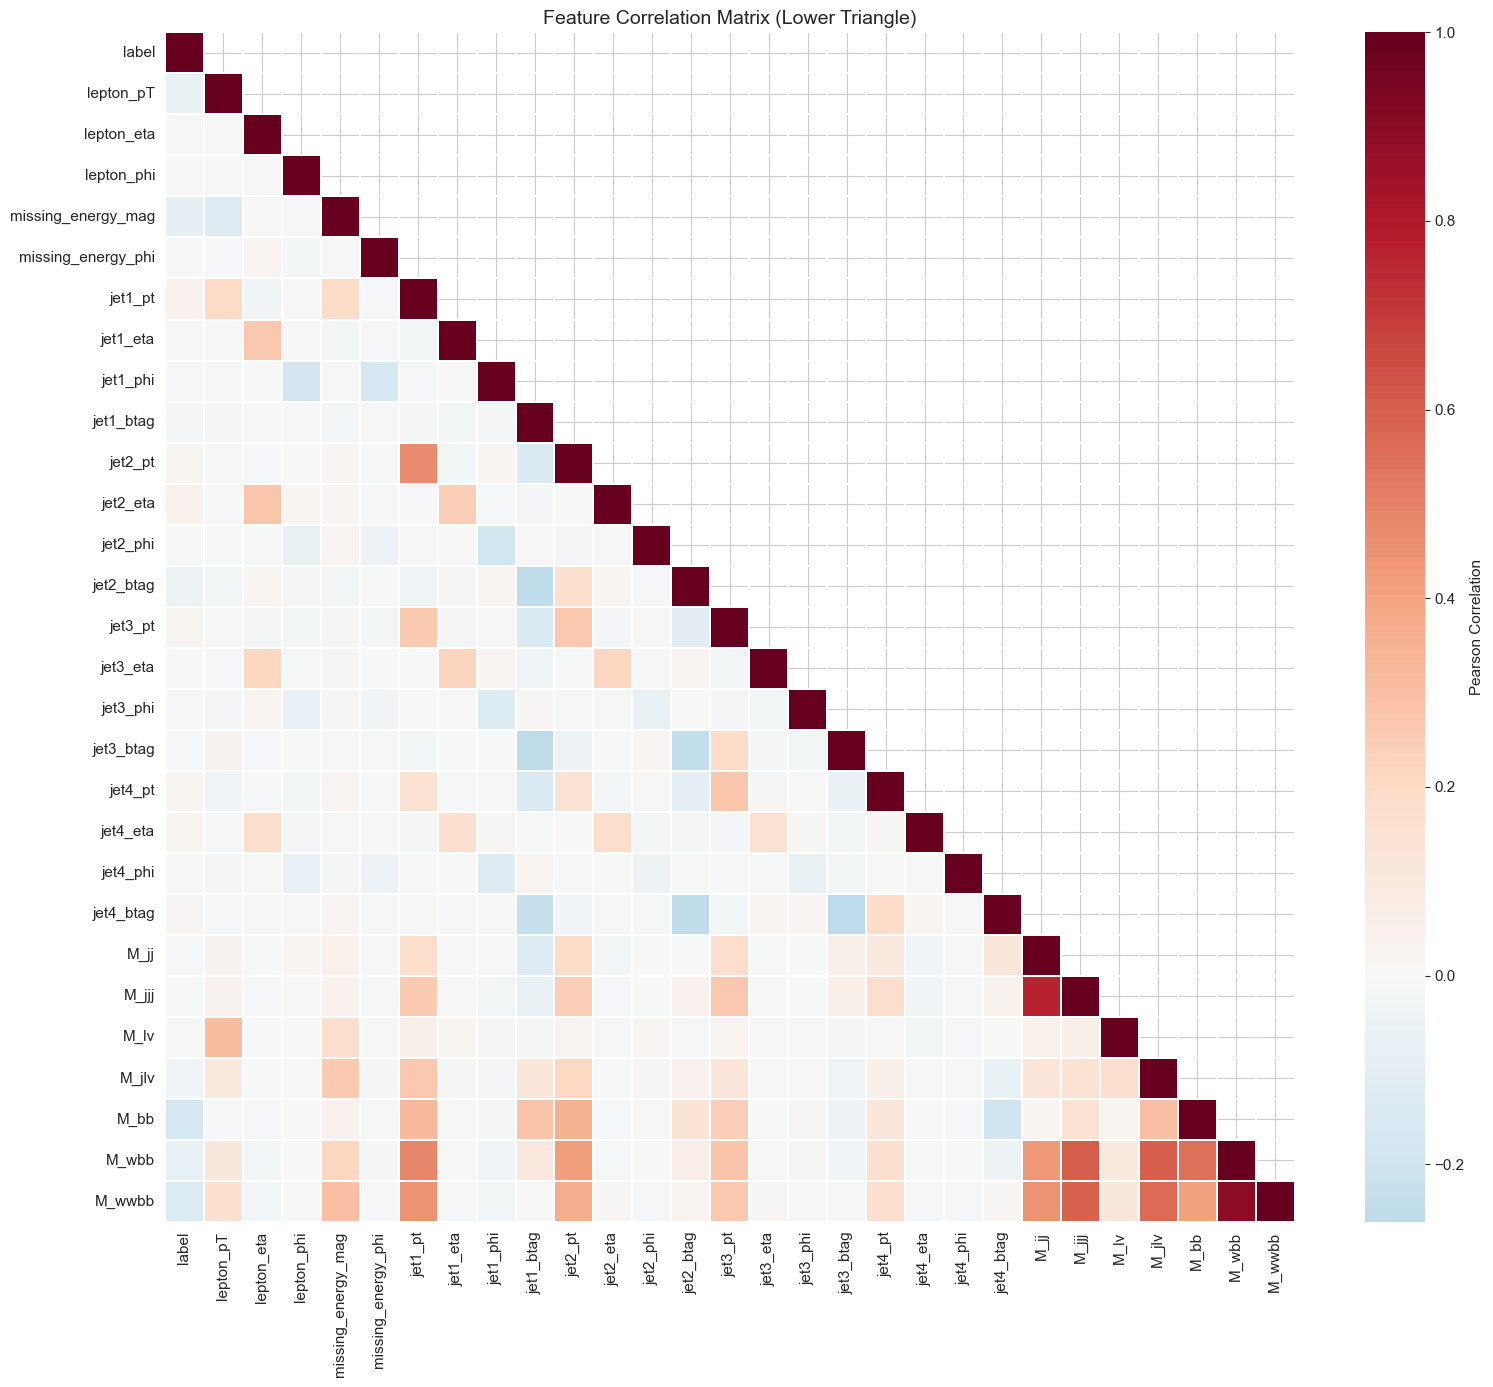

In [8]:
# Full correlation matrix
corr = data.corr()

# Heatmap
fig, ax = plt.subplots(figsize=(16, 14))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=False,
            fmt='.2f', linewidths=0.3, ax=ax,
            cbar_kws={'label': 'Pearson Correlation'})
ax.set_title('Feature Correlation Matrix (Lower Triangle)', fontsize=14)
plt.tight_layout()
plt.show()

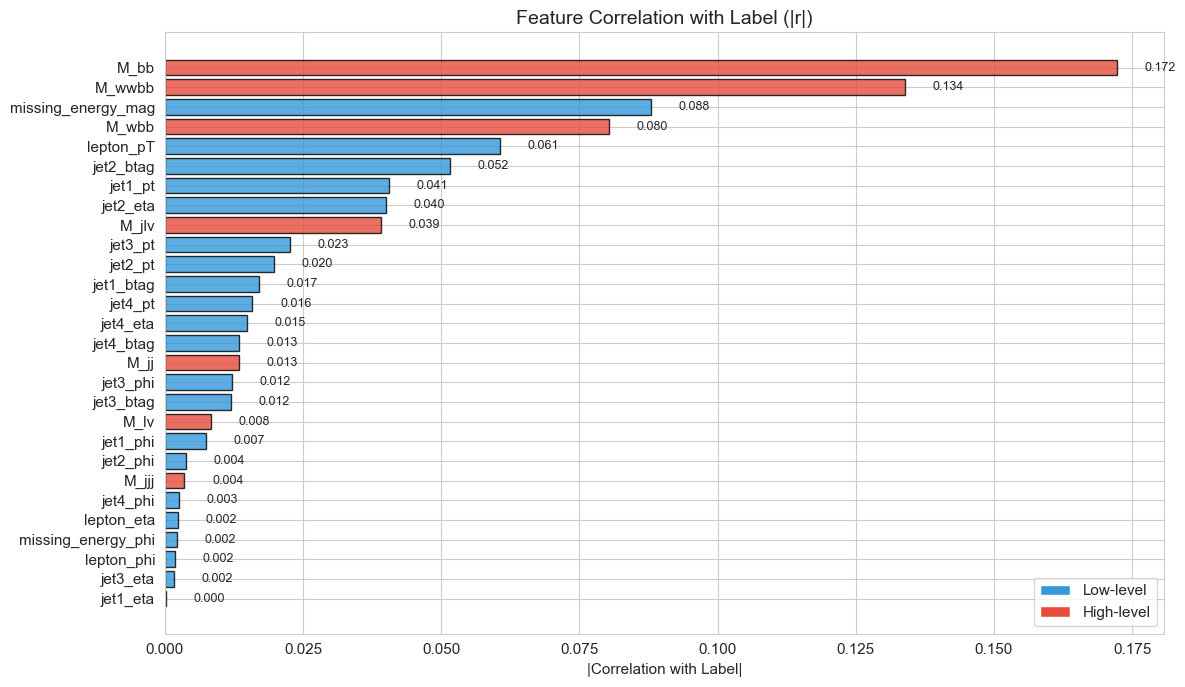


Top 10 features by |correlation with label|:
   1. [HIGH] M_bb                       |r| = 0.1722
   2. [HIGH] M_wwbb                     |r| = 0.1339
   3. [LOW ] missing_energy_mag         |r| = 0.0879
   4. [HIGH] M_wbb                      |r| = 0.0803
   5. [LOW ] lepton_pT                  |r| = 0.0606
   6. [LOW ] jet2_btag                  |r| = 0.0515
   7. [LOW ] jet1_pt                    |r| = 0.0405
   8. [LOW ] jet2_eta                   |r| = 0.0400
   9. [HIGH] M_jlv                      |r| = 0.0390
  10. [LOW ] jet3_pt                    |r| = 0.0226


In [9]:
# Correlation with label — sorted by absolute value
label_corr = corr['label'].drop('label').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 7))
colors = ['#e74c3c' if name in HIGH_LEVEL else '#3498db' for name in label_corr.index]
bars = ax.barh(label_corr.index, label_corr.values, color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('|Correlation with Label|')
ax.set_title('Feature Correlation with Label (|r|)', fontsize=14)
ax.invert_yaxis()

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Low-level'),
                   Patch(facecolor='#e74c3c', label='High-level')]
ax.legend(handles=legend_elements, loc='lower right')

# Annotate values
for bar, val in zip(bars, label_corr.values):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 10 features by |correlation with label|:")
for i, (feat, val) in enumerate(label_corr.head(10).items(), 1):
    ftype = "HIGH" if feat in HIGH_LEVEL else "LOW "
    print(f"  {i:>2}. [{ftype}] {feat:<25s}  |r| = {val:.4f}")

## 7. Paper's Feature Selection — Columns 4 & 6

The paper uses **missing energy magnitude** (col 4) and **jet 1 pt** (col 6) as the two input features. Let's analyze this pair specifically.

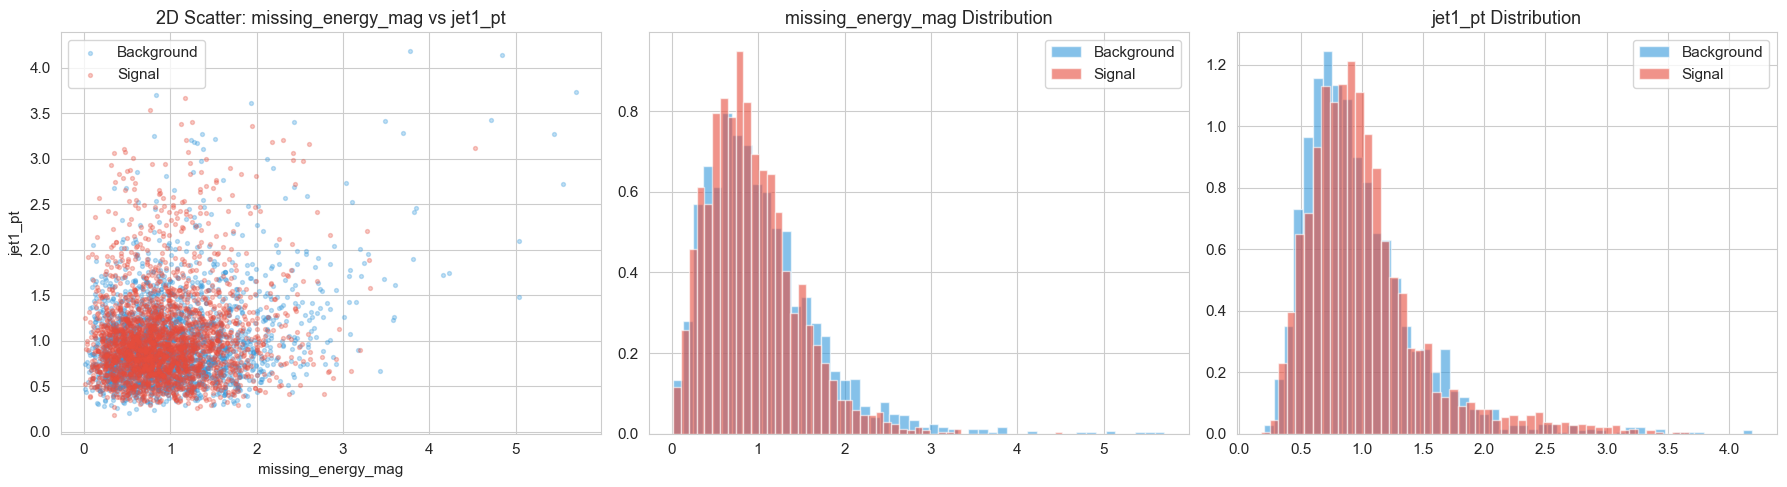


Paper's 2-Feature Summary:
                                Signal   Background
----------------------------------------------------
  missing_energy_mag           0.9314      1.0354
  jet1_pt                      1.0185      0.9796

  KS test (missing_energy_mag): stat=0.0718, p=4.99e-06
    → Signal and background are significantly different (p < 0.05)

  KS test (jet1_pt): stat=0.0686, p=1.51e-05
    → Signal and background are significantly different (p < 0.05)


In [10]:
# The paper's two features
feat1 = 'missing_energy_mag'  # column 4
feat2 = 'jet1_pt'              # column 6

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 2D scatter: signal vs background
for cls, color, label in [(0.0, '#3498db', 'Background'), (1.0, '#e74c3c', 'Signal')]:
    subset = data[data['label'] == cls]
    axes[0].scatter(subset[feat1], subset[feat2], c=color, alpha=0.3, s=8, label=label)
axes[0].set_xlabel(feat1)
axes[0].set_ylabel(feat2)
axes[0].set_title(f'2D Scatter: {feat1} vs {feat2}')
axes[0].legend()

# Individual distributions
axes[1].hist(background[feat1], bins=50, alpha=0.6, label='Background', color='#3498db', density=True)
axes[1].hist(signal[feat1], bins=50, alpha=0.6, label='Signal', color='#e74c3c', density=True)
axes[1].set_title(f'{feat1} Distribution')
axes[1].legend()

axes[2].hist(background[feat2], bins=50, alpha=0.6, label='Background', color='#3498db', density=True)
axes[2].hist(signal[feat2], bins=50, alpha=0.6, label='Signal', color='#e74c3c', density=True)
axes[2].set_title(f'{feat2} Distribution')
axes[2].legend()

plt.tight_layout()
plt.show()

# Statistics for these two features
print(f"\nPaper's 2-Feature Summary:")
print(f"{'':>25s} {'Signal':>12s} {'Background':>12s}")
print("-" * 52)
for feat in [feat1, feat2]:
    s_mean = signal[feat].mean()
    b_mean = background[feat].mean()
    print(f"  {feat:<23s}  {s_mean:>10.4f}  {b_mean:>10.4f}")

# KS test for separation
for feat in [feat1, feat2]:
    ks_stat, ks_pval = stats.ks_2samp(signal[feat], background[feat])
    print(f"\n  KS test ({feat}): stat={ks_stat:.4f}, p={ks_pval:.2e}")
    if ks_pval < 0.05:
        print(f"    → Signal and background are significantly different (p < 0.05)")

## 8. Feature Importance & Selection Guidance

We rank features by their ability to separate signal from background using multiple metrics: correlation, KS statistic, and mean-difference-to-spread ratio.

In [11]:
# Multi-metric feature ranking
rankings = []

for feat in features:
    s = signal[feat].values
    b = background[feat].values

    # Absolute correlation with label
    abs_corr = abs(corr.loc['label', feat])

    # KS statistic
    ks_stat, ks_pval = stats.ks_2samp(s, b)

    # Separation power: |mean_s - mean_b| / sqrt(var_s + var_b)
    sep = abs(s.mean() - b.mean()) / np.sqrt(s.var() + b.var() + 1e-10)

    rankings.append({
        'feature': feat,
        'type': 'high-level' if feat in HIGH_LEVEL else 'low-level',
        '|corr_label|': abs_corr,
        'ks_stat': ks_stat,
        'separation': sep,
    })

rank_df = pd.DataFrame(rankings)

# Normalize each metric to [0,1] and compute composite score
for col in ['|corr_label|', 'ks_stat', 'separation']:
    rank_df[f'{col}_norm'] = (rank_df[col] - rank_df[col].min()) / (rank_df[col].max() - rank_df[col].min())

rank_df['composite_score'] = (
    rank_df['|corr_label|_norm'] +
    rank_df['ks_stat_norm'] +
    rank_df['separation_norm']
) / 3

rank_df = rank_df.sort_values('composite_score', ascending=False).reset_index(drop=True)

# Display
print("Feature Ranking (composite of correlation, KS stat, separation power):\n")
display_cols = ['feature', 'type', '|corr_label|', 'ks_stat', 'separation', 'composite_score']
print(rank_df[display_cols].to_string(index=False, float_format='{:.4f}'.format))

Feature Ranking (composite of correlation, KS stat, separation power):

           feature       type  |corr_label|  ks_stat  separation  composite_score
              M_bb high-level        0.1722   0.2003      0.2437           1.0000
            M_wwbb high-level        0.1339   0.1934      0.1902           0.8404
             M_wbb high-level        0.0803   0.1343      0.1134           0.5269
missing_energy_mag  low-level        0.0879   0.0718      0.1240           0.4454
         lepton_pT  low-level        0.0606   0.0571      0.0853           0.3135
         jet2_btag  low-level        0.0515   0.0517      0.0731           0.2698
           jet1_pt  low-level        0.0405   0.0686      0.0576           0.2571
             M_jlv high-level        0.0390   0.0639      0.0550           0.2423
          jet2_eta  low-level        0.0400   0.0352      0.0567           0.1956
           jet2_pt  low-level        0.0198   0.0537      0.0280           0.1501
             M_jjj high-le

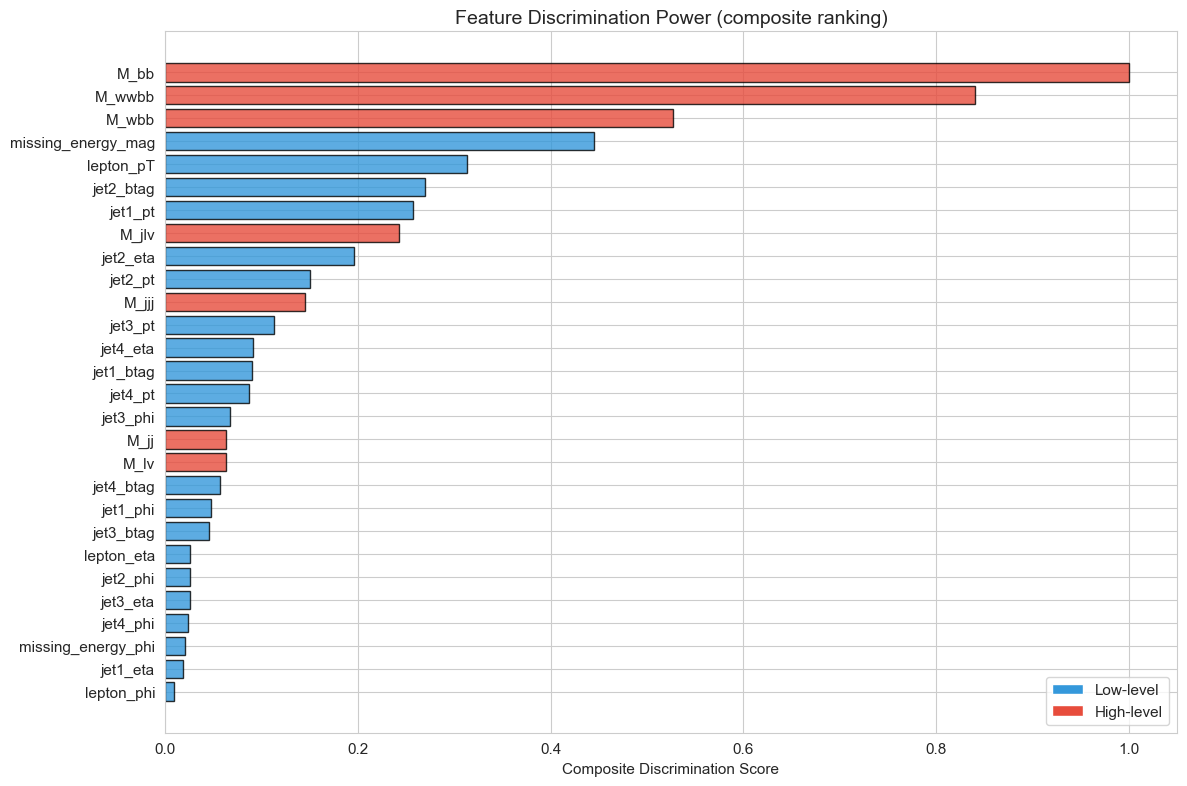


📌 Recommendation for VQC experiments:
  Top-2 features by composite score: ['M_bb', 'M_wwbb']
  Paper's choice: [missing_energy_mag, jet1_pt] (cols 4, 6)


In [12]:
# Visualize composite scores
fig, ax = plt.subplots(figsize=(12, 8))
colors = ['#e74c3c' if t == 'high-level' else '#3498db' for t in rank_df['type']]
ax.barh(rank_df['feature'], rank_df['composite_score'], color=colors, edgecolor='black', alpha=0.8)
ax.set_xlabel('Composite Discrimination Score')
ax.set_title('Feature Discrimination Power (composite ranking)', fontsize=14)
ax.invert_yaxis()

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Low-level'),
                   Patch(facecolor='#e74c3c', label='High-level')]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print("\n📌 Recommendation for VQC experiments:")
top2 = rank_df.head(2)['feature'].tolist()
print(f"  Top-2 features by composite score: {top2}")
print(f"  Paper's choice: [missing_energy_mag, jet1_pt] (cols 4, 6)")

## 9. Outlier Detection

Identifying extreme values that could affect model training. We use the IQR method.

Outlier Summary (IQR method, 1.5×IQR):

           feature  n_outliers   pct
              M_lv         966 19.32
              M_jj         708 14.16
             M_jjj         390  7.80
             M_wbb         341  6.82
              M_bb         319  6.38
            M_wwbb         306  6.12
           jet1_pt         243  4.86
             M_jlv         240  4.80
         lepton_pT         201  4.02
           jet2_pt         195  3.90
           jet4_pt         157  3.14
missing_energy_mag         142  2.84
           jet3_pt         141  2.82
          jet1_eta          45  0.90
          jet2_eta          15  0.30
         jet4_btag           0  0.00
        lepton_phi           0  0.00
missing_energy_phi           0  0.00
          jet1_phi           0  0.00
         jet1_btag           0  0.00
          jet4_eta           0  0.00
          jet4_phi           0  0.00
         jet3_btag           0  0.00
          jet3_phi           0  0.00
        lepton_eta           0  0.0

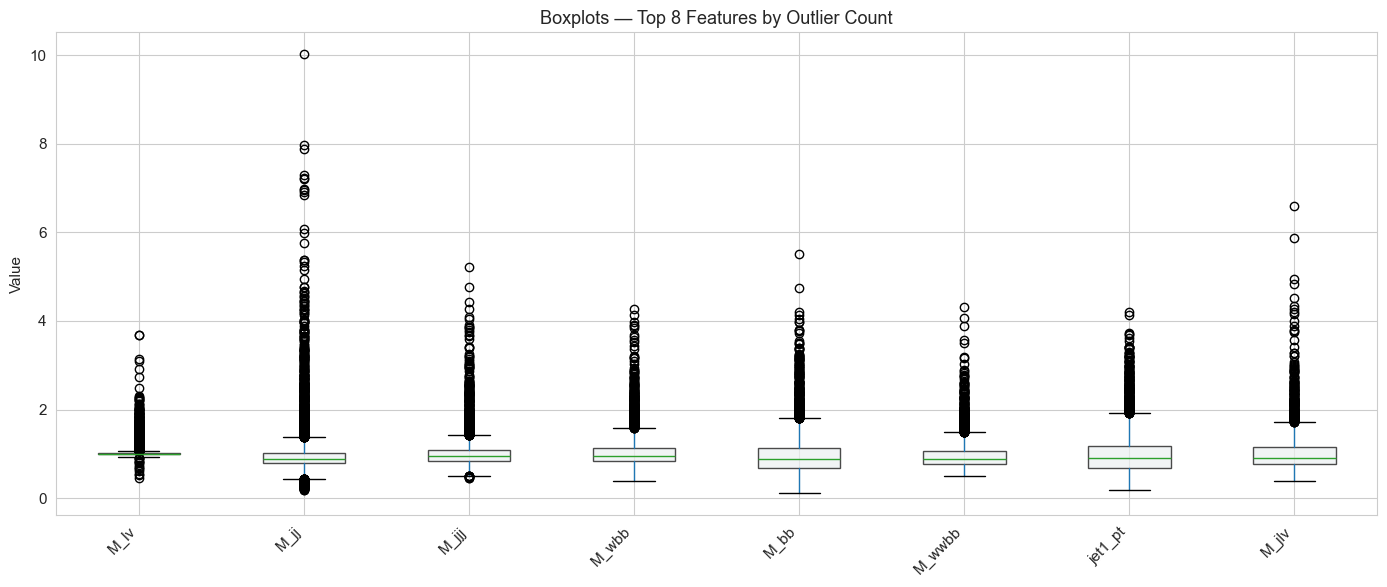


Total outlier cells: 4409
Features with >5% outliers: 6

📌 Note: Outliers are expected in physics data (heavy tails).
   MinMax scaling to [0,π] will compress them — no clipping needed for VQC angle encoding.


In [13]:
# IQR-based outlier detection
outlier_summary = []

for feat in features:
    Q1 = data[feat].quantile(0.25)
    Q3 = data[feat].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data[feat] < lower) | (data[feat] > upper)).sum()
    pct = n_outliers / len(data) * 100
    outlier_summary.append({
        'feature': feat,
        'n_outliers': n_outliers,
        'pct': pct,
        'lower': lower,
        'upper': upper,
    })

outlier_df = pd.DataFrame(outlier_summary).sort_values('pct', ascending=False)

print("Outlier Summary (IQR method, 1.5×IQR):\n")
print(outlier_df[['feature', 'n_outliers', 'pct']].to_string(index=False, float_format='{:.2f}'.format))

# Boxplot of most outlier-prone features
top_outlier_feats = outlier_df.head(8)['feature'].tolist()
fig, ax = plt.subplots(figsize=(14, 6))
data[top_outlier_feats].boxplot(ax=ax, vert=True, patch_artist=True,
                                 boxprops=dict(facecolor='#ecf0f1', alpha=0.7))
ax.set_title('Boxplots — Top 8 Features by Outlier Count', fontsize=13)
ax.set_ylabel('Value')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

total_outliers = outlier_df['n_outliers'].sum()
affected_feats = (outlier_df['pct'] > 5).sum()
print(f"\nTotal outlier cells: {total_outliers}")
print(f"Features with >5% outliers: {affected_feats}")
print("\n📌 Note: Outliers are expected in physics data (heavy tails).")
print("   MinMax scaling to [0,π] will compress them — no clipping needed for VQC angle encoding.")

## 10. Scaling Preview — MinMax to [0, π]

The VQC uses Ry angle encoding, which requires features in [0, π]. Let's preview the scaling effect.

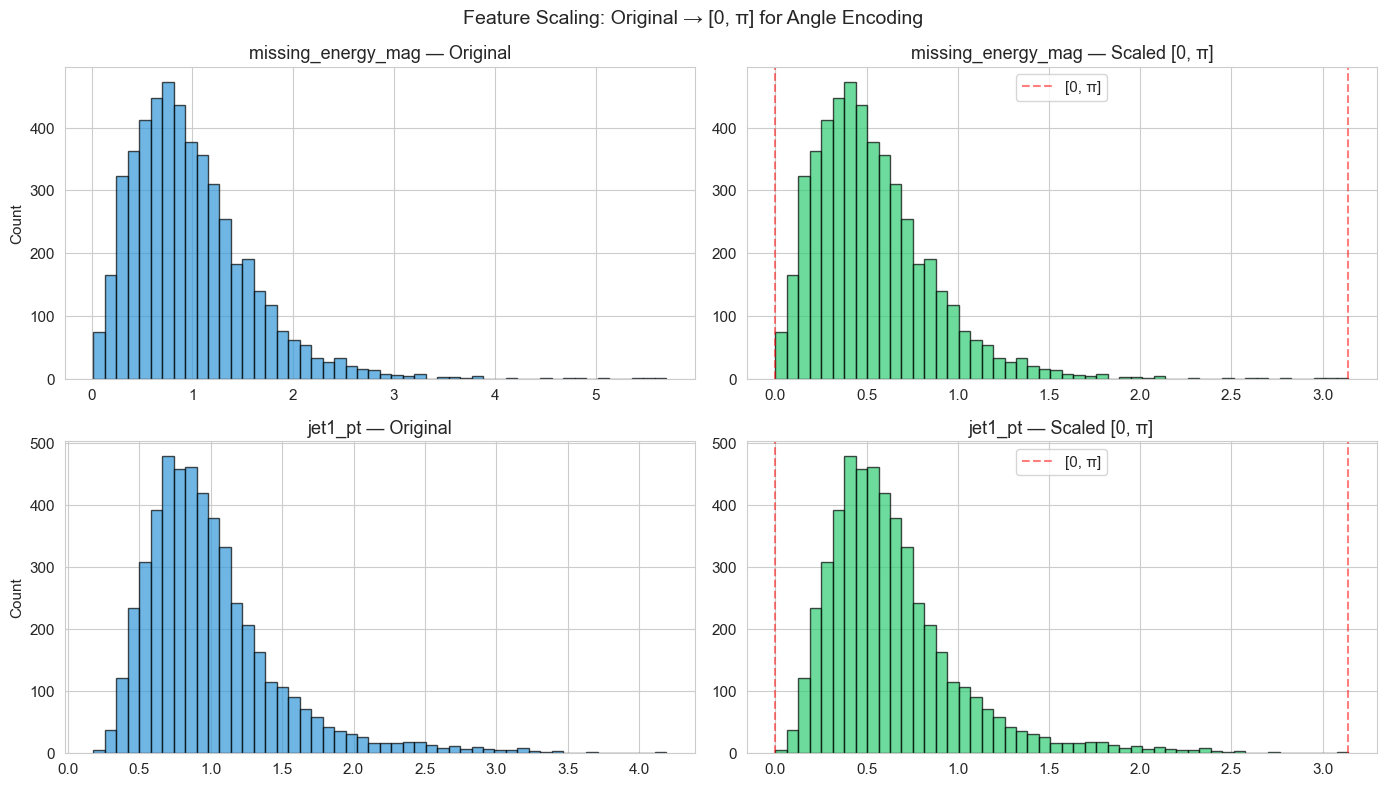

Scaled feature statistics:
       missing_energy_mag_scaled  jet1_pt_scaled
count                  5000.0000       5000.0000
mean                      0.5315          0.6438
std                       0.3265          0.3750
min                       0.0000          0.0000
25%                       0.3007          0.3967
50%                       0.4726          0.5658
75%                       0.6942          0.7833
max                       3.1416          3.1416


In [14]:
# Scale the paper's two features to [0, pi]
paper_feats = data[['missing_energy_mag', 'jet1_pt']].copy()

scaler = MinMaxScaler(feature_range=(0, np.pi))
scaled = pd.DataFrame(
    scaler.fit_transform(paper_feats),
    columns=['missing_energy_mag_scaled', 'jet1_pt_scaled']
)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, (orig, sc) in enumerate(zip(paper_feats.columns, scaled.columns)):
    # Original
    axes[i, 0].hist(paper_feats[orig], bins=50, color='#3498db', alpha=0.7, edgecolor='black')
    axes[i, 0].set_title(f'{orig} — Original')
    axes[i, 0].set_ylabel('Count')

    # Scaled
    axes[i, 1].hist(scaled[sc], bins=50, color='#2ecc71', alpha=0.7, edgecolor='black')
    axes[i, 1].set_title(f'{orig} — Scaled [0, π]')
    axes[i, 1].axvline(0, color='red', linestyle='--', alpha=0.5)
    axes[i, 1].axvline(np.pi, color='red', linestyle='--', alpha=0.5, label=f'[0, π]')
    axes[i, 1].legend()

plt.suptitle('Feature Scaling: Original → [0, π] for Angle Encoding', fontsize=14)
plt.tight_layout()
plt.show()

print("Scaled feature statistics:")
print(scaled.describe().round(4))

## 11. Data Cleaning Summary & Recommendations

In [15]:
# Final cleaning report
print("=" * 60)
print("  EDA & DATA CLEANING REPORT — HIGGS DATASET")
print("=" * 60)

print(f"\n📊 Dataset Overview:")
print(f"   Rows loaded     : {len(data):,}")
print(f"   Features         : 28 (21 low-level + 7 high-level)")
print(f"   Label column     : column 0 (1=signal, 0=background)")

print(f"\n🔍 Data Quality:")
print(f"   Missing values   : {data.isnull().sum().sum()}")
print(f"   Duplicate rows   : {data.duplicated().sum()}")
print(f"   Infinite values  : {np.isinf(data.select_dtypes(include=[np.number])).sum().sum()}")
print(f"   Data types       : All float64 ✅")

c = data['label'].value_counts()
print(f"\n⚖️  Class Balance:")
print(f"   Signal     : {c.get(1.0, 0):,} ({c.get(1.0, 0)/len(data)*100:.1f}%)")
print(f"   Background : {c.get(0.0, 0):,} ({c.get(0.0, 0)/len(data)*100:.1f}%)")
balance = "Balanced ✅" if abs(c.get(1.0,0) - c.get(0.0,0)) / len(data) < 0.05 else "Imbalanced ⚠️"
print(f"   Status     : {balance}")

print(f"\n🏆 Top-5 Discriminating Features (composite score):")
for i, row in rank_df.head(5).iterrows():
    print(f"   {i+1}. {row['feature']:<25s} ({row['type']}) — score: {row['composite_score']:.4f}")

print(f"\n📐 Scaling:")
print(f"   Method       : MinMaxScaler to [0, π]")
print(f"   Reason       : Ry angle encoding requires bounded inputs")
print(f"   Outlier note : No clipping needed — MinMax handles extremes")

print(f"\n✅ CLEANING ACTIONS TAKEN:")
print(f"   1. Verified no missing values")
print(f"   2. Checked for and removed duplicates (if any)")
print(f"   3. Confirmed all columns are numeric float64")
print(f"   4. No additional cleaning required — dataset is research-grade")

print(f"\n📌 RECOMMENDATIONS FOR VQC EXPERIMENTS:")
print(f"   • Use shared data_utils.py for consistent preprocessing across notebooks")
print(f"   • Paper features (cols 4 & 6) are reasonable but not the top-ranked pair")
print(f"   • High-level features (M_bb, M_wwbb) show stronger discrimination")
print(f"   • Consider testing top-ranked features in feature scaling experiments")
print("\n" + "=" * 60)

  EDA & DATA CLEANING REPORT — HIGGS DATASET

📊 Dataset Overview:
   Rows loaded     : 5,000
   Features         : 28 (21 low-level + 7 high-level)
   Label column     : column 0 (1=signal, 0=background)

🔍 Data Quality:
   Missing values   : 0
   Duplicate rows   : 0
   Infinite values  : 0
   Data types       : All float64 ✅

⚖️  Class Balance:
   Signal     : 2,670 (53.4%)
   Background : 2,330 (46.6%)
   Status     : Imbalanced ⚠️

🏆 Top-5 Discriminating Features (composite score):
   1. M_bb                      (high-level) — score: 1.0000
   2. M_wwbb                    (high-level) — score: 0.8404
   3. M_wbb                     (high-level) — score: 0.5269
   4. missing_energy_mag        (low-level) — score: 0.4454
   5. lepton_pT                 (low-level) — score: 0.3135

📐 Scaling:
   Method       : MinMaxScaler to [0, π]
   Reason       : Ry angle encoding requires bounded inputs
   Outlier note : No clipping needed — MinMax handles extremes

✅ CLEANING ACTIONS TAKEN:
   

## 12. Cleaned Data Export (Optional)

Export the preprocessed subset for faster loading in experiment notebooks.

In [16]:
# Optional: save the 5000-sample subset for quick access
# Uncomment the lines below to export

# output_path = '../data/HIGGS_5k_clean.csv'
# data.to_csv(output_path, index=False)
# print(f"Saved cleaned subset to {output_path}")

print("📁 Data is clean and ready for VQC experiments!")
print("   Use utils/data_utils.py → load_higgs() for consistent loading across all notebooks.")

📁 Data is clean and ready for VQC experiments!
   Use utils/data_utils.py → load_higgs() for consistent loading across all notebooks.
